# Neural Network Loan Approval Classification

Train a feed-forward neural network on the normalized SMOTE (or without SMOTE) training set and evaluates it on the untouched normalized test set. Hyperparameters are selected using `RandomizedSearchCV` with k-fold `StratifiedKFold` cross-validation.

# Initialization and Data Preparation

### Load data

In [77]:
from pathlib import Path

import numpy as np
import pandas as pd

seed = 1
np.random.seed(seed)

PROJECT_ROOT = Path("..")
INPUT_DIR = PROJECT_ROOT / "data" / "pre-processed"
OUTPUT_DIR = PROJECT_ROOT / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_df = pd.read_csv(INPUT_DIR / "loan_data_nn_normal_test.csv")

### SMOTE ###
# train_df = pd.read_csv(INPUT_DIR / "loan_data_nn_normal_train_smote.csv")
# model_path = OUTPUT_DIR / "neural_network_smote.joblib" 

### No SMOTE ###
train_df = pd.read_csv(INPUT_DIR / "loan_data_nn_normal_train.csv")
model_path = OUTPUT_DIR / "neural_network.joblib"


print("NN train data shape :", train_df.shape)
train_df.head()

print("NN test data shape :", test_df.shape)
test_df.head()

NN train data shape : (35994, 22)
NN test data shape : (8999, 22)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_education,person_gender_female,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_status
0,-0.463739,1.369131,-0.403218,-0.092478,0.405692,-1.027551,-0.738520,1.002550,4,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,-0.463739,0.174487,-0.909689,0.856475,-0.461448,0.346606,-0.738520,0.149009,4,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.802748,-0.792654,-0.403218,-0.851641,-0.006116,0.003067,-0.480176,-0.744232,3,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,-0.463739,-0.559800,-0.234394,0.777396,1.182436,2.178815,-0.996864,-0.625133,1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,-0.972253,0.080888,-0.740865,1.489111,-0.712550,0.919172,-0.480176,-0.863330,1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0


### Data Checks

In [78]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print()
print("Train columns:", train_df.columns.tolist())
print()
print("Missing values in training data:", train_df.isna().sum().sum())
print("Missing values in test data:", test_df.isna().sum().sum())
print("Train duplicate rows:", train_df.duplicated().sum())
print("Test duplicate rows:", test_df.duplicated().sum())

print()
print("Training target distribution:")
print(train_df["loan_status"].value_counts())
print()
print("Test target distribution:")
print(test_df["loan_status"].value_counts())

Train shape: (35994, 22)
Test shape: (8999, 22)

Train columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_education', 'person_gender_female', 'person_gender_male', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_status']

Missing values in training data: 0
Missing values in test data: 0
Train duplicate rows: 0
Test duplicate rows: 0

Training target distribution:
loan_status
0    27994
1     8000
Name: count, dtype: int64

Test target distribution:
loan_status
0    6999
1    2000
Name: count, dtype: int64


### Create Training and Testing Data Matrices and Response Vectors

The input files are already normalized and one-hot encoded, so no additional scaling or encoding needed

In [79]:
response_col = "loan_status"

X_train = train_df.drop(columns=[response_col])
y_train = train_df[response_col]

X_test = test_df.drop(columns=[response_col])
y_test = test_df[response_col]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("All predictors numeric:", X_train.select_dtypes(exclude=np.number).empty)

X_train shape: (35994, 21)
y_train shape: (35994,)
X_test shape: (8999, 21)
y_test shape: (8999,)
All predictors numeric: True


# Neural Network Implementation

### Neural Network Tuning

In [80]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

nn_model = MLPClassifier(
    solver="adam",
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=12,
    random_state=seed,
)

param_distributions = {
    "model__hidden_layer_sizes": [(32,), (64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": loguniform(1e-5, 1e-2),
    "model__learning_rate_init": loguniform(1e-4, 5e-3),
    "model__batch_size": [64, 128, 256],
}

nn_pipeline = Pipeline([
    ("model", nn_model),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

nn_search = RandomizedSearchCV(
    estimator=nn_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

nn_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__activation=tanh, model__alpha=0.009807412289900458, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.00032632772421791866; total time=   5.4s
[CV] END model__activation=tanh, model__alpha=0.009807412289900458, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.00032632772421791866; total time=   6.5s
[CV] END model__activation=tanh, model__alpha=5.108188686258303e-05, model__batch_size=128, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.000456088071202065; total time=   6.8s
[CV] END model__activation=tanh, model__alpha=0.009807412289900458, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.00032632772421791866; total time=   7.1s
[CV] END model__activation=tanh, model__alpha=0.009807412289900458, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.000326327724217

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__activation': ['relu', 'tanh'], 'model__alpha': <scipy.stats....t 0x1462798b0>, 'model__batch_size': [64, 128, ...], 'model__hidden_layer_sizes': [(32,), (64,), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyex

### Best Hyperparameters and Cross-Validation Results

In [81]:
print("Best CV F1 score:", round(nn_search.best_score_, 4))
print("Best parameters:")
for name, value in nn_search.best_params_.items():
    print(f"{name}: {value}")

search_results = pd.DataFrame(nn_search.cv_results_).sort_values("rank_test_score")
search_results[["rank_test_score", "mean_train_score", "mean_test_score", "std_test_score", "mean_fit_time", "params"]].head(10)

Best CV F1 score: 0.7311
Best parameters:
model__activation: relu
model__alpha: 7.394161323427766e-05
model__batch_size: 64
model__hidden_layer_sizes: (128,)
model__learning_rate_init: 0.002618207010568573


,rank_test_score,mean_train_score,mean_test_score,std_test_score,mean_fit_time,params
9,1,0.741854,0.731104,0.007958,3.445441,"{'model__activation': 'relu', 'model__alpha': ..."
17,2,0.750891,0.730240,0.008964,6.546010,"{'model__activation': 'tanh', 'model__alpha': ..."
15,3,0.744405,0.729412,0.004986,4.282004,"{'model__activation': 'relu', 'model__alpha': ..."
1,4,0.742921,0.729176,0.013476,7.604671,"{'model__activation': 'tanh', 'model__alpha': ..."
18,5,0.751297,0.728241,0.010158,4.691388,"{'model__activation': 'tanh', 'model__alpha': ..."
19,6,0.753650,0.727885,0.008868,5.369724,"{'model__activation': 'relu', 'model__alpha': ..."
14,7,0.751245,0.727843,0.005128,2.420397,"{'model__activation': 'relu', 'model__alpha': ..."
5,8,0.742974,0.727681,0.007090,2.546122,"{'model__activation': 'relu', 'model__alpha': ..."
12,9,0.735516,0.727672,0.008885,8.830100,"{'model__activation': 'tanh', 'model__alpha': ..."
16,10,0.735012,0.727041,0.010118,11.569000,"{'model__activation': 'tanh', 'model__alpha': ..."


### Test Set Evaluation

In [82]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

best_nn_model = nn_search.best_estimator_
class_labels = best_nn_model.named_steps["model"].classes_
y_proba = best_nn_model.predict_proba(X_test)[:, 1]
y_pred = best_nn_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
by_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test precision:", round(precision_score(y_test, y_pred), 4))
print("Test recall:", round(recall_score(y_test, y_pred), 4))
print("Test F1 score:", round(f1_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, y_proba), 4))

print()
print("Confusion matrix: Row = actual class, Column = predicted class")
print(cm)
print()
print("By-class accuracy:")
for class_label, accuracy in zip(class_labels, by_class_accuracy):
    print(f"Class {class_label}: {accuracy:.4f}")

print()
print("Classification report:")
print(classification_report(y_test, y_pred))

Test accuracy: 0.8997
Test precision: 0.8801
Test recall: 0.635
Test F1 score: 0.7377
Test ROC-AUC: 0.9044
Test PR-AUC: 0.8288

Confusion matrix: Row = actual class, Column = predicted class
[[6826  173]
 [ 730 1270]]

By-class accuracy:
Class 0: 0.9753
Class 1: 0.6350

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      6999
           1       0.88      0.64      0.74      2000

    accuracy                           0.90      8999
   macro avg       0.89      0.81      0.84      8999
weighted avg       0.90      0.90      0.89      8999



### Confusion Matrix

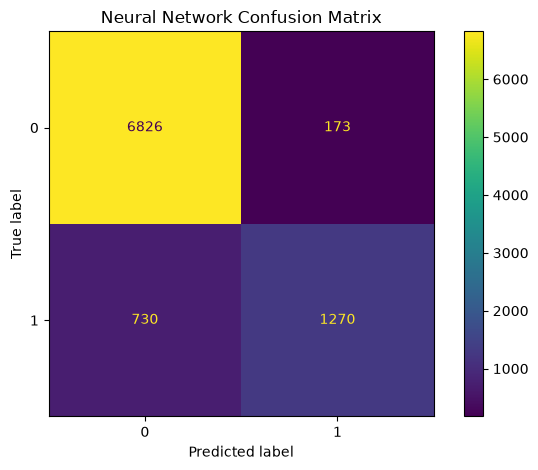

In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(values_format="d")
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

### ROC Curve

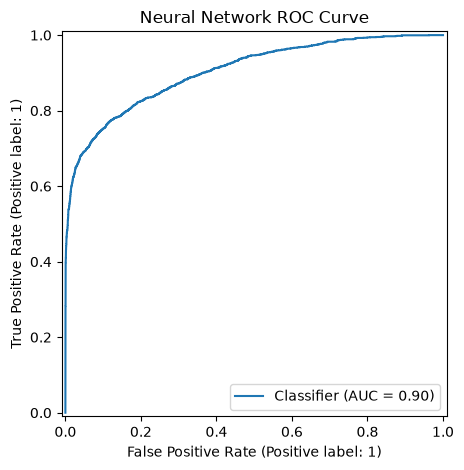

In [84]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Neural Network ROC Curve")
plt.tight_layout()
plt.show()

### Precision-Recall Curve

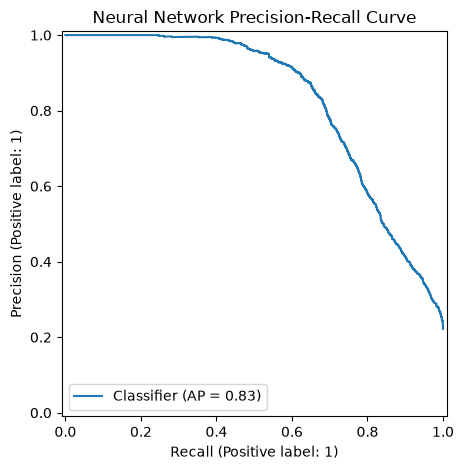

In [85]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Neural Network Precision-Recall Curve")
plt.tight_layout()
plt.show()

### Training History of the Best Model

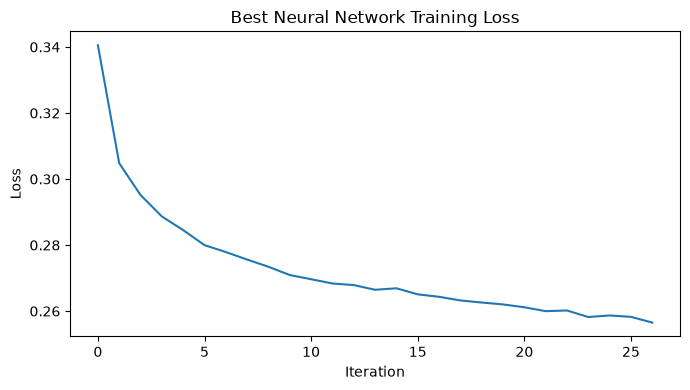

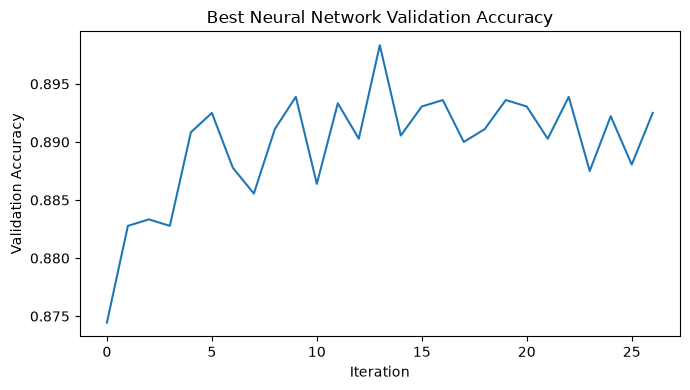

Iterations used: 27
Final training loss: 0.256509


In [86]:
best_mlp = best_nn_model.named_steps["model"]

plt.figure(figsize=(7, 4))
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Best Neural Network Training Loss")
plt.tight_layout()
plt.show()

if best_mlp.validation_scores_ is not None:
    plt.figure(figsize=(7, 4))
    plt.plot(best_mlp.validation_scores_)
    plt.xlabel("Iteration")
    plt.ylabel("Validation Accuracy")
    plt.title("Best Neural Network Validation Accuracy")
    plt.tight_layout()
    plt.show()

print("Iterations used:", best_mlp.n_iter_)
print("Final training loss:", round(best_mlp.loss_, 6))

### Save the Tuned Model

In [87]:
from joblib import dump

dump(best_nn_model, model_path)
print("Saved model to:", model_path)

Saved model to: ../models/neural_network.joblib
